# 03 · Modelagem

Baseline sazonal vs LightGBM, para prever os focos do mês seguinte por bioma.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import shap

import sys; sys.path.append("..")
from src import features, models

In [4]:
monthly = pd.read_csv("../data/processed/focos_mensais.csv", parse_dates=["mes"])
df = features.add_features(monthly)
df.head()

,bioma,mes,focos,lag_1,lag_2,lag_3,lag_12,media_movel_3,mes_sin,mes_cos,ano
0,Amazônia,2016-01-01,4657,11303.0,16935.0,19469.0,2042.0,15902.333333,0.500000,8.660254e-01,2016
1,Amazônia,2016-02-01,1559,4657.0,11303.0,16935.0,1047.0,10965.000000,0.866025,5.000000e-01,2016
2,Amazônia,2016-03-01,2024,1559.0,4657.0,11303.0,572.0,5839.666667,1.000000,6.123234e-17,2016
3,Amazônia,2016-04-01,1075,2024.0,1559.0,4657.0,762.0,2746.666667,0.866025,-5.000000e-01,2016
4,Amazônia,2016-05-01,895,1075.0,2024.0,1559.0,407.0,1552.666667,0.500000,-8.660254e-01,2016


## Baseline vs modelo

In [5]:
train, test = models.time_split(df, "2024-01-01")
train.shape, test.shape

((288, 11), (72, 11))

In [6]:
baseline_preds = models.seasonal_naive(test)
models.evaluate(test, baseline_preds)

{'MAE': 3505.7638888888887}

In [7]:
model = models.train_lgbm(train)
preds = models.predict(model, test)
models.evaluate(test, preds)

{'MAE': 2702.0515465712774}

## Previsão vs real

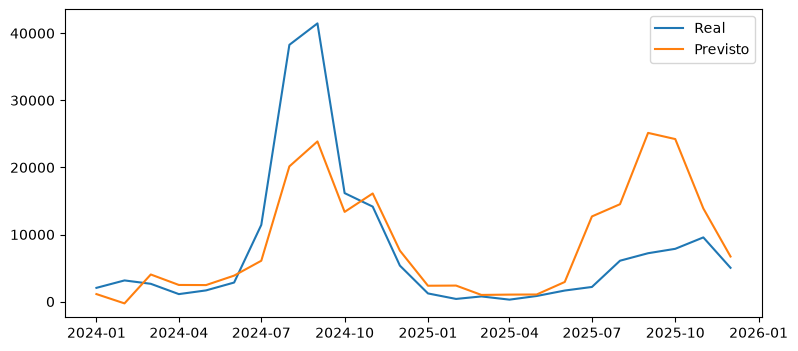

In [11]:
test = test.copy()
test["previsto"] = preds
sub = test[test["bioma"] == "Amazônia"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sub["mes"], sub["focos"], label="Real")
ax.plot(sub["mes"], sub["previsto"], label="Previsto")
ax.legend()

## Importância das variáveis

<Axes: >

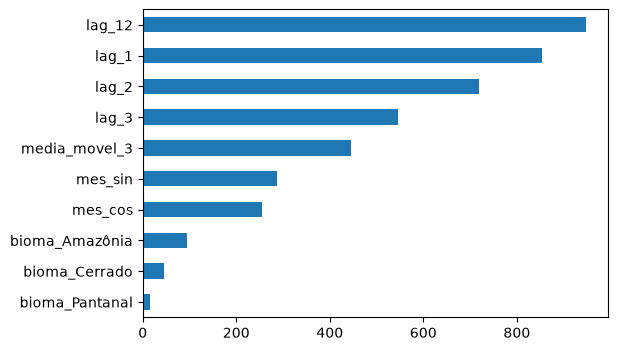

In [12]:
importancia = pd.Series(model.feature_importances_, index=model.feature_name_)
importancia.sort_values().plot.barh(figsize=(6, 4))

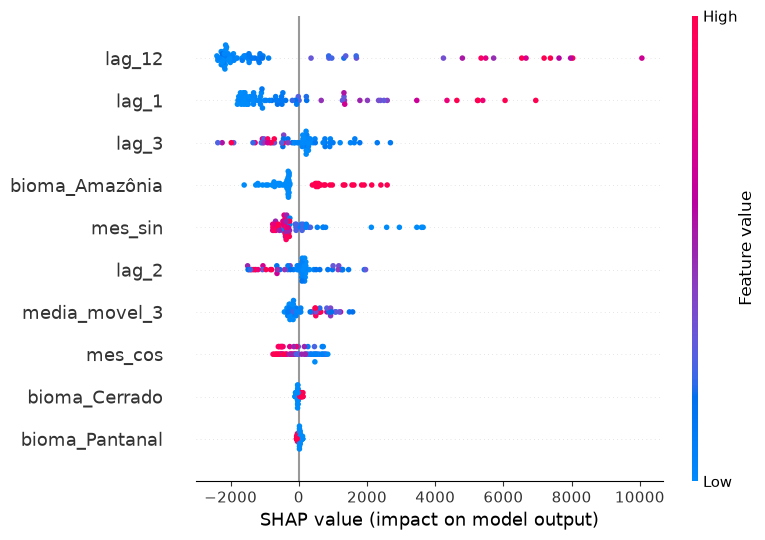

In [13]:
X_test = models.build_X(test, columns=model.feature_name_)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

## Conclusões desta etapa

- **Desempenho:** o LightGBM (MAE ≈ 2.702 focos/mês) superou o baseline sazonal (MAE ≈ 3.506), uma redução de cerca de 23% no erro médio, no período de teste (2024 e 2025, três biomas juntos).
- **Onde o modelo erra:** na Amazônia, ele subestimou o pico extremo de 2024 e superestimou o de 2025. Como usa só o histórico, tende a repetir o padrão recente e não antecipa mudanças bruscas.
- **Variáveis mais importantes:** o mesmo mês do ano anterior (`lag_12`) e os meses imediatamente anteriores (`lag_1`, `lag_2`) foram as que mais pesaram, tanto na importância do modelo quanto no SHAP. O bioma teve peso pequeno.
- **Limitações:** o teste tem só 24 meses e inclui o ano atípico de 2024; o MAE é dominado pela Amazônia, que tem mais focos; e ainda não há variáveis de clima, então não dá para comparar "histórico vs clima".
- **Próximos passos:** avaliar o erro por bioma, testar outros cortes de teste e incluir dados de precipitação para verificar se explicam picos como o de 2024.